# Minimalist Emulsion Polymerization Model

## 📖 Introduction

[Emulsion polymerization] (EP) is a particular form of heterogeneous radical polymerization. Chain initiation occurs in the aqueous phase, while propagation takes place predominantly inside monomer-swollen polymer particles. These particles (typically 10-1000 nm in diameter) may either be present from the outset or form during the process itself.

![Emulsion mechanism](mechep.png){width=450px align=center}

The mechanism and kinetics of EP differ both qualitatively and quantitatively from those of conventional (bulk or solution) radical polymerization, which is reflected in a distinct modeling approach. This notebook introduces a minimalist model of EP, focusing on the essential elements needed to capture monomer consumption rate, particle growth, and particle nucleation. To keep the model tractable, several aspects of the system are deliberately neglected or treated in a highly simplified manner.

We assume a system consisting of a single monomer, a single thermal initiator, and a single surfactant. Furthermore, all particles are assumed to be identical in size and composition (the monodisperse approximation). Under these assumptions, the overall reaction scheme can be written as:

\begin{align*}
I                                        & \xrightarrow{k_{\mathrm{d}}}                         2  R^{\mathrm{w}}_0      \\
R^{\mathrm{w}}_i     + M^{\mathrm{w}}    & \xrightarrow{k_{\mathrm{p}}^{\mathrm{w}}}               R^{\mathrm{w}}_{i+1}  \\
R^{\mathrm{w}}_i     + R^{\mathrm{w}}_j  & \xrightarrow{k_{\mathrm{t}}^{\mathrm{w}}} (1-\alpha^{\mathrm{w}}) P^{\mathrm{w}}_{i+j} + \alpha^{\mathrm{w}} \left( P^{\mathrm{w}}_i + P^{\mathrm{w}}_j \right) \\
\\
R^{\mathrm{w}}_i    + \mathrm{micelle}   & \xrightarrow{k_{\mathrm{em}}}  R^{\mathrm{p}}_i + \mathrm{particle}     \\
R^{\mathrm{w}}_i    + \mathrm{particle}  & \xrightarrow{k_{\mathrm{ep}}}  R^{\mathrm{p}}_i \; \mathrm{(particle)}  \\
R^{\mathrm{p}}_i \; \mathrm{(particle)}  & \xrightarrow{k_{\mathrm{des}}} R^{\mathrm{w}}_i + \mathrm{particle}     \\
\\
R^{\mathrm{p}}_i     + M^{\mathrm{p}}    & \xrightarrow{k_{\mathrm{p}}^{\mathrm{p}}}                R^{\mathrm{p}}_{i+1}  \\
R^{\mathrm{p}}_i     + R^{\mathrm{p}}_j  & \xrightarrow{k_{\mathrm{t}}^{\mathrm{p}}}  (1-\alpha^{\mathrm{p}}) P^{\mathrm{p}}_{i+j} + \alpha^{\mathrm{p}} \left( P^{\mathrm{p}}_i + P^{\mathrm{p}}_j \right)
\end{align*}

The first block corresponds to aqueous-phase reactions, the second to phase-transfer events, and the last to particle-phase reactions. The superscripts $w$ and $p$ denote the aqueous and particle phases, respectively.  


**Material Balances**

For a semibatch process operated in a well-stirred tank vessel, the mole balances take the form:

\begin{equation}
\frac{\mathrm{d}n_i}{\mathrm{d}t} = \dot{n}^{\mathrm{in}}_{i} + \mathcal{R}_i V^{\mathrm{w}}
\end{equation}

where $n_i$, $\dot{n}^{\mathrm{in}}_{i}$ and $\mathcal{R}_i$ denote, respectively, the number of moles, the molar inflow rate, and the rate of production of species $i$, while $V^{\mathrm{w}}$ represents the volume of the aqueous phase. Note that the rate $\mathcal{R}_i$ is defined *per unit volume of the aqueous phase*, which is common practice in EP modeling. 

The relevant components in this model are the initiator ($I$), monomer ($M$), polymer ($P$), surfactant ($S$), and water ($W$). Their corresponding formation rates are:

\begin{align}
\mathcal{R}_{I} &= -\mathcal{R}_{\mathrm{d}}                                                        \\
\mathcal{R}_{M} &= -\mathcal{R}_{\mathrm{p}}^{\mathrm{w}} - \mathcal{R}_{\mathrm{p}}^{\mathrm{p}}   \\
\mathcal{R}_{P} &= -\mathcal{R}_{M}                                                                 \\ 
\mathcal{R}_{S} &= 0                                                                                \\   
\mathcal{R}_{W} &= 0  
\end{align}

Here, $\mathcal{R}_{\mathrm{d}}$ is the rate of initiator decomposition, while $\mathcal{R}_{\mathrm{p}}^{\mathrm{w}}$ and $\mathcal{R}_{\mathrm{p}}^{\mathrm{p}}$ are the polymerization rates in the aqueous and particle phases, respectively. The first two reaction rates follow expressions analogous to those used in conventional solution polymerization:

\begin{align}
\mathcal{R}_{\mathrm{d}}              &= k_{\mathrm{d}} [I]  \\
\mathcal{R}_{\mathrm{p}}^{\mathrm{w}} &= k_{\mathrm{p}}^{\mathrm{w}} [M^{\mathrm{w}}] [R^{\mathrm{w}}]
\end{align}

where $[R^{\mathrm{w}}] = \sum_i [R_i^{\mathrm{w}}]$ is the total concentration (0th moment) of aqueous-phase radicals. In contrast, the expression for $\mathcal{R}_{\mathrm{p}}^{\mathrm{p}}$ takes a distinct form due to the particulate nature of the polymer phase:

\begin{equation}
\begin{aligned}
\mathcal{R}^{\mathrm{p}}_{\mathrm{p}} 
    &= k^{\mathrm{p}}_{\mathrm{p}} [M^{\mathrm{p}}] [R^{\mathrm{p}}] \frac{V^{\mathrm{p}}}{V^{\mathrm{w}}} \\
    &= k^{\mathrm{p}}_{\mathrm{p}} [M^{\mathrm{p}}] \frac{\bar{n} N_{\mathrm{p}}}{N_{\mathrm{A}} V^{\mathrm{p}}} \frac{V^{\mathrm{p}}}{V^{\mathrm{w}}} \\
    &= \frac{k^{\mathrm{p}}_{\mathrm{p}} [M^{\mathrm{p}}] \bar{n}}{N_{\mathrm{A}}} \frac{N_{\mathrm{p}}}{V^{\mathrm{w}}}
\end{aligned}
\end{equation}

Here, $\bar{n}$ is the average number of radicals per particle, $N_{\mathrm{p}}$ is the total number of particles, and $N_{\mathrm{A}}$ is Avogadro's number. 

The value of $\bar{n}$ is governed by a dynamic balance between radical entry (or absorption), radical exit (or desorption), and intraparticle termination. This balance is described by the [Smith–Ewart] equations, which yield the following quasi-steady-state solution:

\begin{equation}
\bar{n} = \frac{a}{4} \frac{I_m(a)}{I_{m-1}(a)}
\end{equation}

Here, $I_m(a)$ denotes the modified Bessel function of the first kind of order $m$ and argument $a=\sqrt{8\alpha}$. The parameter $\alpha=\rho_{\mathrm{e}}/c$ is the dimensionless entry frequency, while $m=k_{\mathrm{des}}/c$ is the dimensionless desorption frequency. The parameter $c=k^{\mathrm{p}}_{\mathrm{t}}/(N_{\mathrm{A}} v_{\mathrm{p}})$ is the pseudo-first-order termination rate coefficient, where $v_{\mathrm{p}}$ is the particle volume. Note that $\rho_{\mathrm{e}}$, $k_{\mathrm{des}}$, and $c$ all have units of s⁻¹.

```{admonition} Radical compartmentalization
:class: dropdown tip

In a bulk or solution system, any two radicals can terminate with one another. In a particulate system, however, termination can only occur between radicals located within the _same_ particle. As a result, for a given number of radicals, the overall termination rate is effectively reduced.

This phenomenon is known as radical *compartmentalization* and explains why the expression for $\bar{n}$ in emulsion polymerization is more involved than its single-phase counterpart, $[R]=\sqrt{r_{\mathrm{ini}}/(2 k_t)}$. 

When the average number of radicals per particle becomes large, the effect of compartmentalization weakens and the system approaches *pseudo-bulk* behavior. In this limit, $\bar{n} \approx \sqrt{\rho_{\mathrm{e}}/(2 c)}$, consistent with the bulk/solution expression.
```     

The equations above are fairly standard and widely accepted. To proceed further, however, we still need expressions for both $[R^{\mathrm{w}}]$ and $\bar{n}$, which in turn requires estimates for $\rho_{\mathrm{e}}$ and $k_{\mathrm{des}}$. This is where theoretical treatments begin to diverge significantly. Here, we deliberately adopt the simplest possible approach.

**Radical Entry**

The radical entry frequency depends on the concentration of radicals in the aqueous phase and on their probability of entering particles. In this simplified model, all aqueous-phase radicals (regardless of chain length or chemical identity) are assumed to have the same entry probability, which leads to:

\begin{equation}
\begin{aligned}
\rho_{\mathrm{e}} &= \sum _i k_{\mathrm{ep}(i)} [R_i^{\mathrm{w}}] \\
                  &= k_{\mathrm{ep}} \sum _i  [R_i^{\mathrm{w}}]   \\
                  &= k_{\mathrm{ep}} [R^{\mathrm{w}}]
\end{aligned}
\end{equation}

where $k_{\mathrm{ep}}$ is the rate coefficient for radical entry into particles. Since we only require the total radical concentration $[R^{\mathrm{w}}]$, rather than the individual species $[R_i^{\mathrm{w}}]$, it is sufficient to write an overall balance for the aqueous-phase radicals:

\begin{equation}
\frac{\mathrm{d} [R^{\mathrm{w}}]}{\mathrm{d}t} =
    2 f k_{\mathrm{d}} [I] - 2 k_{\mathrm{t}}^{\mathrm{w}} [R^{\mathrm{w}}]^2 
    - k_{\mathrm{ep}} [R^{\mathrm{w}}] \frac{N_{\mathrm{p}}}{N_{\mathrm{A}} V^{\mathrm{w}}} 
    - k_{\mathrm{em}} [R^{\mathrm{w}}] \frac{N_{\mathrm{m}}}{N_{\mathrm{A}} V^{\mathrm{w}}} 
    + k_{\mathrm{des}} \bar{n} \frac{N_{\mathrm{p}}}{N_{\mathrm{A}} V^{\mathrm{w}}}
\end{equation}

Here, $N_{\mathrm{m}}$ denotes the number of surfactant micelles and $k_{\mathrm{em}}$ is the corresponding micellar entry coefficient. Because radicals are fast, short-lived species, this balance is usually not integrated directly. Instead, the quasi-steady-state radical concentration is obtained by setting the time derivative to zero. Note that the desorption term couples this balance to the expression for $\bar{n}$, so the two equations must be solved simultaneously.

Since all aqueous-phase radicals are lumped into $[R^{\mathrm{w}}]$, the entry coefficients $k_{\mathrm{ep}}$ and $k_{\mathrm{em}}$ must be interpreted as empirical average parameters. In this notebook, we estimate them using simple formulas from diffusion theory:

\begin{align}
k_{\mathrm{ep}} & = 4 \pi r_{\mathrm{p}} N_{\mathrm{A}} \mathscr{D}_{R^{\mathrm{w}}} f_{\mathrm{ep}} \\
k_{\mathrm{em}} & = 4 \pi r_{\mathrm{m}} N_{\mathrm{A}} \mathscr{D}_{R^{\mathrm{w}}} f_{\mathrm{em}}
\end{align}

where $\mathscr{D}_{R^{\mathrm{w}}}$ is the diffusivity of the radicals in the aqueous phase, $r_{\mathrm{p}}$ and $r_{\mathrm{m}}$ are, respectively, the particle and micelle radii, and $f_{\mathrm{e}}$ is the efficiency of radical entry into particles or micelles.

The entry coefficient is a *second-order* rate coefficient. It is helpful to think of entry as a combination step (analogous to termination) between a radical and a particle. For this reason, the entry terms in the radical balance are written as the product of a molar radical concentration and a molar particle concentration. The entry coefficient therefore has SI units of m³/(mol·s). When using concentrations expressed in mol/L, as is customary in chemical kinetics, the coefficient should be converted to units of L/(mol·s).


**Radical Exit**

It is commonly assumed that only *monomeric* radicals — formed, for example, by transfer to monomer inside the particles — have a significant probability of desorption. Even under this assumption, the desorption coefficient $k_{\mathrm{des}}$ remains deceptively complex to interpret and estimate. The reason is that $k_{\mathrm{des}}$ plays a double role: it must account both for the fraction of the total radical population, $N\bar{n}$, that is effectively monomeric and for the escape rate of these monomeric radicals. Moreover, because desorbed radicals can reenter particles, the fraction of monomeric radicals *inside* the particles depends on processes occurring *outside* the particles. This coupling is rather counterintuitive. 

For the purposes of this simple EP model, $k_{\mathrm{des}}$ is estimated using the Nomura-Asua equation:

\begin{equation}
k_{\mathrm{des}} = 
k_{\mathrm{fm}}^{\mathrm{p}} [M^{\mathrm{p}}] 
\frac{\mathscr{D}_0 r_{\mathrm{p}}^{-2}}
{\beta \mathscr{D}_0 r_{\mathrm{p}}^{-2} + k_{\mathrm{p}}^{\mathrm{p}}[M^{\mathrm{p}}]}
\end{equation}

where $k_{\mathrm{fm}}^{\mathrm{p}}$ is the transfer-to-monomer rate coefficient, $\mathscr{D}_0$ is the effective diffusivity of the monomeric radicals, and $\beta$ is the probability that a desorbed radical undergoes propagation or termination in the aqueous phase. Given the reaction paths considered in our model, this probability is given by:

\begin{equation}
\beta = \frac
{
k_{\mathrm{p}}^{\mathrm{w}} [M^{\mathrm{w}}] 
+ 2 k_{\mathrm{t}}^{\mathrm{w}} [R^{\mathrm{w}}]
}
{
k_{\mathrm{p}}^{\mathrm{w}} [M^{\mathrm{w}}] 
+ 2 k_{\mathrm{t}}^{\mathrm{w}} [R^{\mathrm{w}}] 
+ k_{\mathrm{ep}} \frac{N_{\mathrm{p}}}{N_{\mathrm{A}} V^{\mathrm{w}}} 
+ k_{\mathrm{em}} \frac{N_{\mathrm{m}}}{N_{\mathrm{A}} V^{\mathrm{w}}}
}
\end{equation}

**Monomer Partitioning**

The monomer can dissolve in both the aqueous and particle phases and, if present in sufficient quantity, may also form a separate droplet phase. Because mass transfer between phases is typically fast with respect to monomer consumption, it is reasonable to assume that thermodynamic equilibrium is maintained at all times. Under this assumption, the total monomer balance can be written as:

\begin{equation}
\begin{aligned}
n_{M} &= n_{M}^{\mathrm{w}} + n_{M}^{\mathrm{p}} + n_{M}^{\mathrm{d}}  \\
      &= [M^{\mathrm{w}}] V^{\mathrm{w}} + [M^{\mathrm{p}}] V^{\mathrm{p}} + n_{M}^{\mathrm{d}}  \\
      &= [M^{\mathrm{w}}] V^{\mathrm{w}} + \frac{[M^{\mathrm{p}}] v_{P}}{1 - [M^{\mathrm{p}}] v_{M}} n_{P} + n_{M}^{\mathrm{d}}
\end{aligned}
\end{equation}

where $v_i$ is the molar volume of species $i$. 

If monomer droplets are present ($n_{\mathrm{M}}^{\mathrm{d}} > 0$), the monomer concentration in both the aqueous and particle phases equals the corresponding saturation value. Otherwise, the monomer distributes between the two phases according to thermodynamic equilibrium. In this notebook, we use a simple semi-empirical relation to connect the monomer concentrations:

\begin{equation}
\frac{[M^{\mathrm{w}}]}{[M^{\mathrm{w}}_{\mathrm{sat}}]} = \left( \frac{[M^{\mathrm{p}}]}{[M^{\mathrm{p}}_{\mathrm{sat}}]} \right)^{0.6}
\end{equation}


**Surfactant Partitioning**

The surfactant can be present in four different forms: as free molecules in the aqueous phase, in micelles, adsorbed on the polymer particles, and adsorbed on monomer droplets. Neglecting the last contribution and assuming the system remains in dynamic equilibrium at all times, the overall surfactant balance can be written as:

\begin{equation}
\begin{aligned}
n_{S} &= n_{S}^{\mathrm{w}} + n_{S}^{\mathrm{p}} + n_{S}^{\mathrm{m}}  \\
      &= [S^{\mathrm{w}}] V^{\mathrm{w}} + \Gamma (4 \pi r_{\mathrm{p}}^2 N_{\mathrm{p}}) + \frac{a_{\mathrm{m}}}{N_{\mathrm{A}}} N_{\mathrm{m}}
\end{aligned}
\end{equation}

Here, $\Gamma$ denotes the surface concentration of surfactant adsorbed on the particles, and $a_{\mathrm{m}}$ is the aggregation number of the micelles. The surfactant partitions between the aqueous phase and the particle surface according to an adsorption isotherm. In this notebook, we assume that this distribution is described by a Langmuir isotherm:

\begin{equation}
\Gamma = \Gamma_{\infty} \frac{K_S [S^{\mathrm{w}}]}{1 + K_S [S^{\mathrm{w}}]}
\end{equation}

where $\Gamma_{\infty}$ is the limiting surface concentration and $K_S$ is the adsorption constant. Once the aqueous surfactant concentration $[S^{\mathrm{w}}]$ reaches the critical micellar concentration (CMC), any additional surfactant is assumed to form micelles.


**Particle Formation**

Particle formation is, in general, a complex process involving multiple nucleation and coagulation mechanisms. In this notebook, we make a drastic simplification: particles are assumed to form exclusively via micellar (heterogeneous) nucleation, and coagulation is neglected altogether. Under these assumptions, the rate of particle formation is given by:

\begin{equation}
\frac{\mathrm{d} N_{\mathrm{p}}}{\mathrm{d}t} = k_{\mathrm{em}} [R^{\mathrm{w}}] N_{\mathrm{m}}
\end{equation}

where $N_{\mathrm{p}}(0)$ denotes the initial number of seed particles (if present).

The monodisperse approximation means the whole polymer mass is concentrated in a unique particle size. Accordingly, the unswollen (excluding the monomer) particle radius is given by: 

\begin{equation}
r_{\mathrm{p,u}} = \left( \frac{n_{P} v_{P}}{\frac{4}{3} \pi N_{\mathrm{p}}} \right)^{\frac{1}{3}}
\end{equation}

and the swollen (including the monomer) particle radius is:

\begin{equation}
r_{\mathrm{p}} = r_{\mathrm{p,u}}  \left( 1 - [M^{\mathrm{p}}] v_{M} \right)^{-\frac{1}{3}}
\end{equation}

Admittedly, this is a rather long detour for a minimalist model. At this point, it is time to switch gears and start writing actual code to solve the equations introduced above.

[Emulsion polymerization]: https://en.wikipedia.org/wiki/Emulsion_polymerization
[Smith–Ewart]: https://doi.org/10.1063/1.1746951

## 🧮 Model Implementation

### Architecture

This model is the most complex one in this series of tutorials, so it is essential to organize the code in a modular way. The diagram below provides a high-level overview of the model architecture: `solve_model` advances the system by calling SciPy’s `solve_ivp`, which repeatedly evaluates `model_xdot` to compute the state derivatives.

Within each evaluation, `model_xdot` calls `model_aux`, which computes the auxiliary variables required by the model equations. In turn, `model_aux` evaluates the partitioning relations through `monomer_partition` and `surfactant_partition`, while delegating the kinetic calculations to `model_rates`.

The `model_rates` function obtains the temperature-dependent rate constants from `arrhenius` and evaluates the radical kinetics through `radical_balance`, which itself relies on `entry_coefficient` and `exit_coefficient` to compute the radical entry and exit contributions.

After the integration is complete, `solve_model` calls `model_aux` once more to reconstruct the time evolution of the auxiliary variables using the computed state-variable solution as input.

```{mermaid}
graph TD
    solve_model[solve_model]
    solve_ivp[solve_ivp]
    model_xdot[model_xdot]
    model_aux[model_aux]
    model_rates[model_rates]
    radical_balance[radical_balance]
    entry_coefficient[entry_coefficient]
    exit_coefficient[exit_coefficient]
    surfactant_partition[surfactant_partition]
    monomer_partition[monomer_partition]
    arrhenius[arrhenius]
    
    solve_model --> solve_ivp
    solve_model --> model_aux
    solve_ivp --> model_xdot
    model_xdot --> model_aux
    model_aux --> monomer_partition
    model_aux --> surfactant_partition
    model_aux --> model_rates
    model_rates --> arrhenius
    model_rates --> radical_balance
    radical_balance --> entry_coefficient
    radical_balance --> exit_coefficient
```

### Code Implementation

In [1]:
# %pip install polykin

In [2]:
from enum import IntEnum

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from polykin.kinetics import nbar_Li_Brooks
from scipy.constants import Avogadro as NA

To improve code readability, we define an enum mapping the variable names to the corresponding row index in the state vector and related arrays.

In [3]:
class Ix(IntEnum):
    """Species index."""
    I = 0  # Initiator
    M = 1  # Monomer
    P = 2  # Polymer
    S = 3  # Surfactant
    W = 4  # Water

First, we implement a helper function `arrhenius` to describe the temperature dependence of the rate coefficients.

In [4]:
def arrhenius(T: float, k0: float, Ea: float, T0: float) -> float:
    """Arrhenius equation.

    Parameters
    ----------
    T : float
        Temperature (°C).
    k0 : float
        Value of rate coefficient at `T0` (#/s).
    Ea : float
        Energy of activation (J/mol).
    T0 : float
        Reference temperature (°C).

    Returns
    -------
    float
        Value of rate coefficient at `T`.
    """
    R = 8.314  # J/(mol·K)
    return k0 * np.exp(-Ea / R * (1/(273.15 + T) - 1/(273.15 + T0)))

Next, we implement the monomer partitioning algorithm. We first assume that the droplet phase is present and compute the corresponding amount. If the result is positive, then a droplet phase indeed exists. Otherwise, no droplet phase is present, and the partitioning is solved considering only the aqueous and particle phases.

For numerical stability, it is essential that the algorithm can correctly handle slightly *negative* monomer amounts or concentrations. This unphysical situation can occur at very low monomer contents (i.e., high instantaneous conversion), where the ODE solver may return — or transiently explore — small negative values. In such cases, the partitioning calculation must return a mathematically consistent slightly negative concentration, which then drives the solution back toward zero.

In [5]:
def monomer_partition(
    n_M: float, n_P: float, Vw: float, T: float, params: dict
) -> tuple[float, ...]:
    """Solve for monomer partitioning between aqueous, particle, and droplet
    phases.

    Parameters
    ----------
    n_M : float
        Amount of monomer (mol)
    n_P : float
        Amount of polymer (mol)
    Vw : float
        Volume of water phase (L)
    T : float
        Temperature (°C)
    params : dict
        Model parameters.

    Returns
    -------
    tuple[float, ...]
        Mw, Mp, n_Mw, n_Mp, n_Md
    """

    # Return early if no monomer is present
    if n_M == 0.0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    # Extract parameters
    Mw_sat = params['monomer-partition']['Mw_sat']
    Mp_sat = params['monomer-partition']['Mp_sat']
    vm_M = params['vm'][Ix.M]
    vm_P = params['vm'][Ix.P]

    def monomer_equilibrium(x: float) -> float:
        "Monomer equilibrium relationship between water and particle phases."
        return Mw_sat*np.sign(x)*abs(x)**0.6  # Trick to allow x < 0

    def monomer_balance(x: float, droplets: bool = False) -> tuple:
        "Total monomer balance across all phases."
        Mp = x*Mp_sat
        Mw = monomer_equilibrium(x)
        n_Mw = Mw*Vw
        n_Mp = ((Mp*vm_P)/(1 - Mp*vm_M))*n_P
        n_Md = n_M - (n_Mw + n_Mp) if droplets else 0.0
        Δn_M = n_M - (n_Mw + n_Mp + n_Md)
        return Mw, Mp, n_Mw, n_Mp, n_Md, Δn_M

    # Assume monomer droplets are present, saturating both phases
    Mw, Mp, n_Mw, n_Mp, n_Md, _ = monomer_balance(1.0, droplets=True)
    droplets_present = (n_Md > 0.0)

    # Otherwise, solve for monomer distribution
    if not droplets_present:
        try:
            sol = root_scalar(lambda x: monomer_balance(x)[-1],
                            bracket=[-0.1, 1.0],  # Trick to allow x < 0
                            method='brentq', xtol=1e-6)
        except Exception as e:
            raise RuntimeError("Monomer partition failed.") from e
        
        if sol.converged:
            Mw, Mp, n_Mw, n_Mp, n_Md, _ = monomer_balance(sol.root)
        else:
            raise RuntimeError(
                f"Monomer partition failed. Flag: {sol.flag}, Root: {sol.root}")

    return Mw, Mp, n_Mw, n_Mp, n_Md

From a mathematical perspective, surfactant partitioning is quite similar to monomer partitioning. Therefore, the same considerations apply, and a similar algorithm is used.

In [6]:
def surfactant_partition(
    n_S: float, Ap: float, Vw: float, T: float, params: dict
) -> tuple[float, ...]:
    """Solve for surfactant partitioning between water, particle surface, and
    micelles.

    Parameters
    ----------
    n_S : float
        Amount of surfactant (mol)
    Ap : float
        Area of particles (m²)
    Vw : float
        Volume of water phase (L)
    T : float
        Temperature (°C)
    params : dict
        Model parameters.

    Returns
    -------
    tuple[float, ...]
        Sw, Sp, Nm, n_Sw, n_Sp, n_Sm
    """

    # Return early if no surfactant is present
    if n_S == 0.0:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

    # Extract parameters
    CMC = params['surfactant-partition']['CMC']
    K = params['surfactant-partition']['K']
    Γinf = params['surfactant-partition']['Γinf']
    am = params['surfactant-partition']['am']

    def surfactant_isotherm(Sw: float) -> float:
        "Langmuir adsorption isotherm."
        return (Γinf*K*Sw)/(1 + K*Sw)

    def surfactant_balance(x: float, micelles: bool = False) -> tuple:
        "Total surfactant balance across all phases."
        Sw = x*CMC
        Sp = surfactant_isotherm(Sw)
        n_Sw = Sw*Vw
        n_Sp = Sp*Ap
        n_Sm = n_S - (n_Sw + n_Sp) if micelles else 0.0
        Δn_S = n_S - (n_Sw + n_Sp + n_Sm)
        return Sw, Sp, n_Sw, n_Sp, n_Sm, Δn_S

    # Assume micelles exist, saturating both phases
    Sw, Sp, n_Sw, n_Sp, n_Sm, _ = surfactant_balance(1.0, micelles=True)
    micelles_present = (n_Sm > 0.0)

    # Otherwise, solve for surfactant distribution
    if not micelles_present:
        try:
            sol = root_scalar(lambda x: surfactant_balance(x)[-1],
                            bracket=[-0.01, 1.0],  # Trick to allow x < 0
                            method='brentq', xtol=1e-6)
        except Exception as e:
            raise RuntimeError("Surfactant partition failed.") from e

        if sol.converged:
            Sw, Sp, n_Sw, n_Sp, n_Sm, _ = surfactant_balance(sol.root)
        else:
            raise RuntimeError(
                f"Surfactant partition failed. Flag: {sol.flag}, Root: {sol.root}")

    Nm = n_Sm*NA/am

    return Sw, Sp, Nm, n_Sw, n_Sp, n_Sm

Next, we implement the calculation of the entry (or absorption) coefficient according to the irreversible diffusion model. The efficiency argument allows it to be used for both particles and micelles.

In [7]:
def entry_coefficient(r: float, Dw: float, fe: float) -> float:
    """Calculate the entry coefficient for a radical entering a particle or
    a micelle.

    Parameters
    ----------
    r : float
        Particle or micelle radius (m).
    Dw : float
        Diffusivity of radicals in water (m²/s)
    fe : float
        Entry efficiency.

    Returns
    -------
    float
        Entry coefficient (L/(mol·s))
    """
    return 1e3*(4*np.pi*r*NA*Dw*fe)

The exit (or desorption) coefficient it estimated using the Nomura-Asua model.

In [8]:
def exit_coefficient(
    Mp: float, kpp1: float, kfmp: float,
    D0: float, rp: float, beta: float
) -> float:
    """Calculate the exit coefficient for a radical exiting a particle.

    Parameters
    ----------
    Mp : float
        Monomer concentration in particles (mol/L).
    kpp1 : float
        Propagation rate coefficient of a monomeric radical in particles
        (L/(mol·s)).
    kfmp : float
        Transfer-to-monomer rate coefficient in particles (L/(mol·s)).
    D0 : float
        Effective diffusion coefficient of a monomeric radical (m²/s).
    rp : float
        Particle radius (m).
    beta : float
        Probability that a desorbed radical will propagate or terminate in the
        aqueous phase.

    Returns
    -------
    float
        Exit coefficient (s⁻¹).
    """
    K0 = D0/rp**2  # Monomeric radical desorption coefficient (s⁻¹)
    return kfmp*Mp * K0/(K0*beta + kpp1*Mp)

We now combine the entry, exit, and termination terms in a quasi-steady-state balance to determine the aqueous-phase radical concentration and the average number of radicals per particle.

In [9]:
def radical_balance(
    Iw: float, Mw: float, Mp: float,
    f: float, kd: float, kpw: float, ktw: float,
    kpp1: float, ktp: float, kfmp: float,
    rp: float, Np: float, Nm: float, Vw: float,
    params: dict
) -> tuple[float, ...]:
    """Solve for the radical concentration in the aqueous phase.

    Parameters
    ----------
    Iw : float
        Initiator concentration in water (mol/L).
    Mw : float
        Monomer concentration in water (mol/L).
    Mp : float
        Monomer concentration in particles (mol/L).
    f : float
        Initiator efficiency.
    kd : float
        Initiator decomposition rate coefficient (1/s).
    kpw : float
        Propagation rate coefficient in water (L/(mol·s)).
    ktw : float
        Termination rate coefficient in water (L/(mol·s)).
    kpp1 : float
        Propagation rate coefficient of a monomeric radical in particles
        (L/(mol·s)).
    ktp : float
        Termination rate coefficient in particles (L/(mol·s)).
    kfmp : float
        Transfer-to-monomer rate coefficient in particles (L/(mol·s)).
    rp : float
        Particle radius (m).
    Np : float
        Number of particles.
    Nm : float
        Number of micelles.
    Vw : float
        Volume of water phase (L).
    params : dict
        Model parameters.

    Returns
    -------
    tuple[float, ...]
        Rw, nbar, kdes, beta, kep, kem
    """

    # Entry coefficients
    Dw = params['entry']['Dw']
    kep = entry_coefficient(rp, Dw, params['entry']['fep'])
    kem = entry_coefficient(params['entry']['rm'], Dw, params['entry']['fem'])

    # Exit parameters
    D0 = params['exit']['D0']

    # Intra-particle termination
    vp = 1e3*(4/3)*np.pi*rp**3  # L
    c = ktp/(NA*vp) if vp > 0 else np.inf

    # Reference radical concentration
    Rw0 = np.sqrt(Iw*f*kd/ktw)

    # Return early if no radicals are generated
    if Rw0 == 0.0:
        return 0.0, 0.0, 0.0, 0.0, kep, kem

    # Solve for [Rw] using QSSA
    def qssa_balance(x: float) -> tuple:
        Rw = Rw0*x
        ρe = kep*Rw
        beta1 = kpw*Mw + 2*ktw*Rw
        beta2 = kep*Np/(NA*Vw) + kem*Nm/(NA*Vw)
        beta = beta1/(beta1 + beta2)
        if Np > 0 and vp > 0:
            kdes = exit_coefficient(Mp, kpp1, kfmp, D0, rp, beta)
            nbar = nbar_Li_Brooks(ρe/c, kdes/c)
        else:
            kdes = 0.0
            nbar = 0.0
        source = 2*f*kd*Iw + kdes*nbar*Np/(NA*Vw)
        sink = 2*ktw*Rw**2 + kep*Rw*Np/(NA*Vw) + kem*Rw*Nm/(NA*Vw)
        ΔRw = (source - sink)/(2*f*kd*Iw + 1e-20)
        return Rw, nbar, kdes, beta, ΔRw

    try:
        sol = root_scalar(lambda x: qssa_balance(x)[-1],
                          bracket=[1e-10, 1.0],
                          method='brentq',
                          xtol=1e-6)
    except Exception as e:
        raise RuntimeError("Radical balance failed.") from e

    if sol.converged:
        Rw, nbar, kdes, beta, _ = qssa_balance(sol.root)
    else:
        raise RuntimeError(
            f"Radical balance failed. Flag: {sol.flag}, Root: {sol.root}")

    return Rw, nbar, kdes, beta, kep, kem

With the radical balance in place, we can assemble the remaining kinetic expressions needed to evaluate the component formation rates and the particle nucleation rate.

In [10]:
def model_rates(
    n: np.ndarray, Np: float, Nm: float,
    Mw: float, Mp: float, rp: float, Vw: float, T: float,
    params: dict
) -> tuple:
    """Component formation rates, nucleation rate, and radical balance.

    Parameters
    ----------
    n : np.ndarray
        Components moles vector (mol).
    Np : float
        Number of particles.
    Nm : float
        Number of micelles.
    Mw : float
        Monomer concentration in water (mol/L).
    Mp : float
        Monomer concentration in particles (mol/L).
    rp : float
        Particle radius (m).
    Vw : float
        Volume of water phase (L).
    T : float
        Temperature (°C).
    params : dict
        Model parameters.

    Returns
    -------
    tuple
        rates, rate_nuc, Rw, nbar, kdes, beta, kep, kem
    """

    # Kinetic parameters
    kinetics = params['kinetics']
    f = kinetics['f']
    kd = arrhenius(T, **kinetics['kd'])
    kpw = arrhenius(T, **kinetics['kpw'])
    kpp = arrhenius(T, **kinetics['kpp'])
    ktw = arrhenius(T, **kinetics['ktw'])
    ktp = arrhenius(T, **kinetics['ktp'])
    Cfm = arrhenius(T, **kinetics['Cfm'])
    kfmp = kpp*Cfm
    kpp1 = kpp # Approximation

    # Radical balances
    Iw = n[Ix.I]/Vw
    Rw, nbar, kdes, beta, kep, kem = radical_balance(
        Iw, Mw, Mp, f, kd, kpw, ktw, kpp1, ktp, kfmp, rp, Np, Nm, Vw, params)

    # Nucleation rate
    rate_nuc = kem*Rw*Nm

    # Reaction rates
    rate_d = kd*Iw
    rate_pw = kpw*Mw*Rw
    rate_pp = kpp*Mp*nbar*Np/(NA*Vw)

    # Component rates
    rates = np.zeros_like(n)
    rates[Ix.I] = - rate_d
    rates[Ix.M] = - rate_pw - rate_pp
    rates[Ix.P] = - rates[Ix.M]

    return rates, rate_nuc, Rw, nbar, kdes, beta, kep, kem

Next, we implement a function that evaluates the auxiliary variables we want to track over time but do not include in the state vector. This function is used both during the integration and afterward to reconstruct the full solution.

In [11]:
def model_aux(
    t: float, n: np.ndarray, Np: float, recipe: dict, params: dict
) -> dict:
    """Auxiliary model function.

    Parameters
    ----------
    t : float
        Time (s).
    n : np.ndarray
        Components moles vector (mol).
    Np : float
        Number of particles.
    recipe : dict
        Polymerization recipe.
    params : dict
        Model parameters.

    Returns
    -------
    dict
        Auxiliary variables.
    """

    # Temperature
    T = recipe['T'](t)

    # Component masses
    m = n*params['MW']

    # Aqueous phase volume
    vm = params['vm']
    Vw = n[Ix.W]*vm[Ix.W]

    # Monomer partitioning
    Mw, Mp, n_Mw, n_Mp, n_Md = \
        monomer_partition(n[Ix.M], n[Ix.P], Vw, T, params)

    # Phase volumes
    Vd = n_Md*vm[Ix.M]
    Vp = n_Mp*vm[Ix.M] + n[Ix.P]*vm[Ix.P]
    V = Vw + Vp + Vd

    # Particle radius
    rpu = ((n[Ix.P]*vm[Ix.P]/1e3)/(4/3*np.pi*Np))**(1/3) if Np > 0.0 else 0.0
    rpu = max(rpu, 1e-9)  # Avoid unphysically small radius
    rp = rpu/np.cbrt(1 - Mp*vm[Ix.M])

    # Particle surface area
    Ap = 4*np.pi*rp**2*Np

    # Surfactant partitioning
    Sw, Sp, Nm, n_Sw, n_Sp, n_Sm = \
        surfactant_partition(n[Ix.S], Ap, Vw, T, params)

    # Rates and related
    rates, rate_nuc, Rw, nbar, kdes, beta, kep, kem = \
        model_rates(n, Np, Nm, Mw, Mp, rp, Vw, T, params)

    # Component molar feed rates
    feed = recipe['feed']
    MW = params['MW']
    ndot_in = np.zeros_like(n)
    ndot_in[Ix.I] = feed['I'](t)/MW[Ix.I]
    ndot_in[Ix.M] = feed['M'](t)/MW[Ix.M]
    ndot_in[Ix.S] = feed['S'](t)/MW[Ix.S]
    ndot_in[Ix.W] = feed['W'](t)/MW[Ix.W]

    # Pack variables in dict
    y = {
        'm': m,
        'V': V,
        'Vw': Vw,
        'Vp': Vp,
        'Vd': Vd,
        'rpu': rpu,
        'rp': rp,
        'Ap': Ap,
        'Mw': Mw,
        'Mp': Mp,
        'n_Mw': n_Mw,
        'n_Mp': n_Mp,
        'n_Md': n_Md,
        'Sw': Sw,
        'Sp': Sp,
        'Nm': Nm,
        'n_Sw': n_Sw,
        'n_Sp': n_Sp,
        'n_Sm': n_Sm,
        'Rw': Rw,
        'nbar': nbar,
        'kdes': kdes,
        'beta': beta,
        'kep': kep,
        'kem': kem,
        'rate_nuc': rate_nuc,
        'rates': rates,
        'ndot_in': ndot_in,
        'T': T,
    }

    return y

All the required building blocks are now available, so we can implement the derivative of the state vector. This function is relatively compact because most of the model-specific calculations have already been delegated to the helper functions defined above.

In [12]:
def model_xdot(
    t: float, x: np.ndarray, recipe: dict, params: dict
) -> np.ndarray:
    """Calculate the derivative of the state vector, dx/dt.

    x = [n(I), n(M), n(P), n(S), n(W), Np]

    Parameters
    ----------
    t : float
        Time (s).
    x : np.ndarray
        State vector.
    recipe : dict
        Polymerization recipe.
    params : dict
        Model parameters.

    Returns
    -------
    np.ndarray
        Time derivative of the state vector.
    """
    # Unpack the state vector
    n = x[:-1]
    Np = x[-1]

    # Allocate the state vector derivative and respective views
    xdot = np.zeros_like(x)
    ndot = xdot[:-1]
    Npdot = xdot[-1:]

    # Evaluate the auxiliary variables
    y = model_aux(t, n, Np, recipe, params)

    # Material balances
    ndot[:] = y['ndot_in'] + y['rates']*y['Vw']

    # Number of particles balance
    Npdot[:] = y['rate_nuc']

    return xdot

Finally, we perform the numerical integration with a suitable ODE solver.

In [13]:
def solve_model(recipe: dict, params: dict) -> dict:
    """Solve the dynamic model.

    Parameters
    ----------
    recipe : dict
        Polymerization recipe.
    params : dict
        Model parameters.

    Returns
    -------
    dict
        t, n, T, ...
    """

    # Initial component moles
    n0 = recipe['m0']/params['MW']

    # Initial particle number
    dp0 = recipe['d0']
    if dp0 > 0.0:
        Np0 = (n0[Ix.P]*params['vm'][Ix.P]/1e3)/(np.pi/6*dp0**3)
    else:
        Np0 = 0.0

    # Initial conditions
    x0 = np.hstack([n0, Np0])

    solution = solve_ivp(model_xdot,
                         t_span=(0.0, recipe['tend']),
                         y0=x0,
                         args=(recipe, params),
                         method='LSODA',
                         rtol=1e-6,
                         atol=np.hstack([np.full(n0.shape, 1e-6), 1e1]),
                         max_step=120.0)

    # Unpack the solution
    t = solution.t
    x = solution.y
    n = x[:-1]
    Np = x[-1]

    # Compute aux variables
    result = {
        'm': np.empty_like(n),
        'T': np.empty_like(t),
        'V': np.empty_like(t),
        'Vw': np.empty_like(t),
        'Vp': np.empty_like(t),
        'Vd': np.empty_like(t),
        'rpu': np.empty_like(t),
        'Mw': np.empty_like(t),
        'Mp': np.empty_like(t),
        'n_Mw': np.empty_like(t),
        'n_Mp': np.empty_like(t),
        'n_Md': np.empty_like(t),
        'Sw': np.empty_like(t),
        'Sp': np.empty_like(t),
        'Nm': np.empty_like(t),
        'n_Sw': np.empty_like(t),
        'n_Sp': np.empty_like(t),
        'n_Sm': np.empty_like(t),
        'Rw': np.empty_like(t),
        'nbar': np.empty_like(t),
        'kdes': np.empty_like(t),
        'beta': np.empty_like(t),
        'kep': np.empty_like(t),
        'kem': np.empty_like(t),
        'rate_nuc': np.empty_like(t),
        'ndot_in': np.empty_like(n),
    }

    for i in range(t.size):
        aux = model_aux(t[i], n[:, i], Np[i], recipe, params)
        for key in result.keys():
            result[key][..., i] = aux[key]

    result['t'] = t
    result['n'] = n
    result['Np'] = Np

    return result

## 📊 Results and Visualization

We illustrate the main features of the model using three representative cases: batch seeded polymerization, semibatch seeded polymerization, and batch unseeded (*ab initio*) polymerization.

For all cases, we use typical parameter values for a representative emulsion polymerization system, loosely based on styrene with potassium persulfate and sodium dodecyl sulfate. You can adjust these parameters to explore how the predictions change.

In [14]:
params = {
    'MW': np.zeros(len(Ix)),
    'rho': np.ones(len(Ix)),
    'vm': np.zeros(len(Ix)),
    'kinetics': {
        'f': 0.5,
        'kd': {'k0': 1e-6, 'Ea': 140e3, 'T0': 50.0},  # 1/s,
        'kpw': {'k0': 87, 'Ea': 32e3, 'T0': 25.0},    # L/(mol·s)
        'kpp': {'k0': 87, 'Ea': 32e3, 'T0': 25.0},    # L/(mol·s)
        'ktw': {'k0': 1e9, 'Ea': 12e3, 'T0': 50.0},   # L/(mol·s)
        'ktp': {'k0': 2e6, 'Ea': 10e3, 'T0': 50.0},   # L/(mol·s)
        'Cfm': {'k0': 5e-5, 'Ea': 0, 'T0': 50.0},
    },
    'entry': {
        'Dw': 1e-9,   # m²/s
        'rm': 2e-9,   # m
        'fep': 1.0,
        'fem': 1e-3,
    },
    'exit': {
        'D0': 1e-13,   # m²/s
    },
    'monomer-partition': {
        'Mw_sat': 5e-3,  # mol/L
        'Mp_sat': 6.0,   # mol/L
    },
    'surfactant-partition': {
        'CMC': 8e-3,   # mol/L
        'Γinf': 3e-6,  # mol/m²
        'K': 2e3,      # L/mol
        'am': 60,
    }
}

params['MW'][Ix.I] = 0.270  # kg/mol
params['MW'][Ix.M] = 0.104  # kg/mol
params['MW'][Ix.P] = 0.104  # kg/mol
params['MW'][Ix.S] = 0.288  # kg/mol
params['MW'][Ix.W] = 0.018  # kg/mol

params['rho'][Ix.M] = 0.90  # kg/L
params['rho'][Ix.P] = 1.05  # kg/L
params['rho'][Ix.W] = 1.00  # kg/L

params['vm'][:] = params['MW']/params['rho']

### Batch Seeded Polymerization

We first consider an isothermal seeded batch polymerization at 50 °C with an initial seed diameter of 80 nm. The reactor is charged with monomer, water, initiator, surfactant, and a small amount of preformed seed. 

Since the model only considers micellar nucleation, the surfactant concentration is kept below the CMC to suppress additional particle formation.

In [15]:
recipe_batch_seeded = {
    'tend': 10*3.6e3,  # s
    'm0': np.zeros(len(Ix)),
    'd0': 80e-9,  # m
    'T': lambda t: 50.0,  # °C
    'feed': {  # kg/s
        'I': lambda t: 0,
        'M': lambda t: 0,
        'S': lambda t: 0,
        'W': lambda t: 0,
    },
}

recipe_batch_seeded['m0'][Ix.I] = 0.003
recipe_batch_seeded['m0'][Ix.M] = 0.200
recipe_batch_seeded['m0'][Ix.P] = 0.050
recipe_batch_seeded['m0'][Ix.S] = 0.008
recipe_batch_seeded['m0'][Ix.W] = 1.000

We now solve the model for this recipe and examine the resulting concentration, partitioning, and particle growth profiles.

In [16]:
sol_batch_seeded = solve_model(recipe_batch_seeded, params)

To inspect the solution, we use a set of reusable plotting functions.

The first function shows the feed profiles, total reactor volume, and temperature. For this batch recipe, these profiles are relatively trivial, but they provide a useful context check before the more informative kinetic and partitioning results.

In [17]:
def plot_contents(sol: dict) -> None:
    """Plot reactor contents.

    Parameters
    ----------
    sol : dict
        Model solution.
    """

    fig, ax = plt.subplots(3, sharex=True, figsize=(7, 3*2))
    fig.suptitle("Reactor Contents")
    fig.tight_layout()
    fig.align_ylabels()

    t_hour = sol['t']/3600
    ax[-1].set_xlabel("Time (h)")

    # Flow rates
    MW = params['MW']
    for ix in Ix:
        ax[0].plot(t_hour, 3600*sol['ndot_in'][ix, :]*MW[ix], label=ix.name)
    ax[0].set_ylabel("Mass flow (kg/h)")
    ax[0].legend(loc='lower right')
    ax[0].grid(True)

    # Volume
    ax[1].plot(t_hour, sol['V'], label='Total')
    ax[1].set_ylabel("Volume (L)")
    ax[1].grid(True)

    # Temperature
    ax[2].plot(t_hour, sol['T'])
    ax[2].set_ylabel("Temperature (°C)")
    ax[2].grid(True)

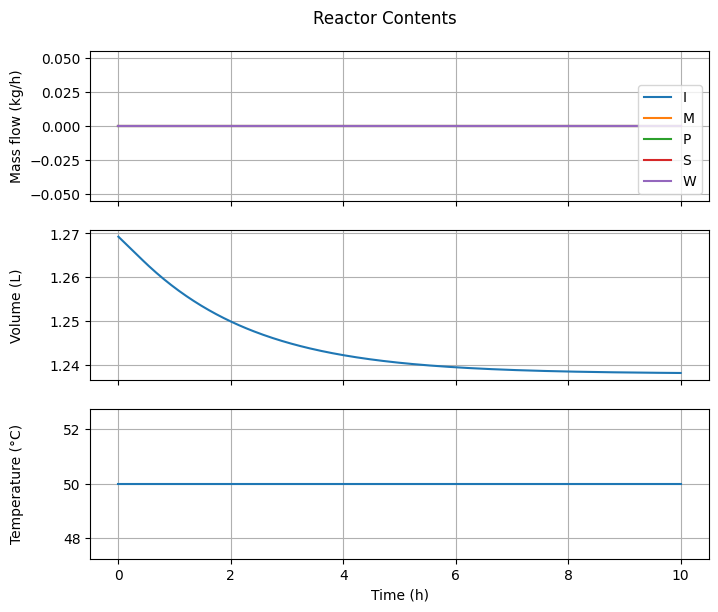

In [18]:
plot_contents(sol_batch_seeded)

As expected for an isothermal batch recipe, all feed rates are zero and the temperature remains constant throughout the run. The total volume decreases, reflecting the higher density of the polymer relative to the monomer.

#### Kinetics

We next examine the variables governing radical production, entry, exit, and monomer conversion.

In [19]:
def plot_kinetics(sol: dict) -> None:
    """Plot kinetic results.

    Parameters
    ----------
    sol : dict
        Model solution.
    """

    fig, ax = plt.subplots(7, sharex=True, figsize=(7, 6*1.5))
    fig.suptitle("Kinetics")
    fig.tight_layout()
    fig.align_ylabels()

    t_hour = sol['t']/3600
    ax[-1].set_xlabel("Time (h)")

    # [I]
    ax[0].plot(t_hour, 1e3*sol['n'][Ix.I, :]/sol['Vw'])
    ax[0].set_ylabel("[I] (mmol/L)")
    ax[0].grid(True)

    # [Rw]
    ax[1].plot(t_hour, sol['Rw'])
    ax[1].set_ylabel(r"$[R^w]$" + " (mol/L)")
    ax[1].grid(True)

    # beta
    ax[2].plot(t_hour, sol['beta'])
    ax[2].set_ylabel(r"$\beta$")
    ax[2].grid(True)

    # Entry coefficients
    ax[3].plot(t_hour, sol['kep'])
    ax[3].set_ylabel(r"$k_{ep}$" + " (L/(mol·s))")
    ax[3].grid(True)

    # Exit coefficient
    ax[4].plot(t_hour, sol['kdes'])
    ax[4].set_ylabel(r"$k_{des}$" + " (s⁻¹)")
    ax[4].grid(True)

    # Average number of radicals per particle
    ax[5].plot(t_hour, sol['nbar'])
    ax[5].set_ylabel(r"$\bar{n}$")
    ax[5].set_ylim(0, 1.1*np.max(sol['nbar']))
    ax[5].grid(True)

    # Instantaneous conversion
    Δn_P = sol['n'][Ix.P] - sol['n'][Ix.P, 0]
    conversion = 1e2*Δn_P/(sol['n'][Ix.M] + Δn_P + 1e-10)
    ax[6].plot(t_hour, conversion)
    ax[6].set_ylabel("Conversion (%)")
    ax[6].grid(True)

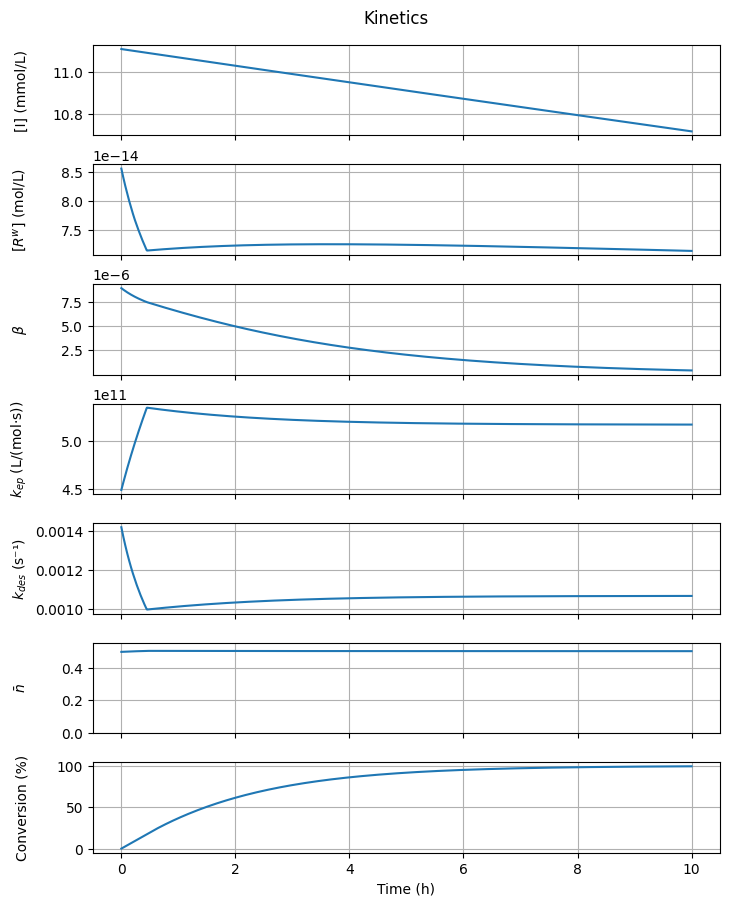

In [20]:
plot_kinetics(sol_batch_seeded)

Two features are worth emphasizing. First, $\beta \ll 1$ over most of the run, as is typical for sparingly water-soluble monomers such as styrene: radicals that desorb from particles predominantly re-enter rather than reacting in the aqueous phase. Second, the predicted value of $\bar{n}$ remains close to 0.5, consistent with the classical zero–one kinetic regime often observed in styrene emulsion polymerization under similar conditions.

#### Monomer Partitioning

The next plot shows how the monomer distributes itself between the aqueous, particle, and droplet phases.

In [21]:
def plot_monomer_partitioning(sol: dict) -> None:
    """Plot monomer partitioning results.

    Parameters
    ----------
    sol : dict
        Model solution.
    """

    fig, ax = plt.subplots(4, sharex=True, figsize=(7, 4*2))
    fig.suptitle("Monomer Partitioning")
    fig.tight_layout()
    fig.align_ylabels()

    t_hour = sol['t']/3600
    ax[-1].set_xlabel("Time (h)")

    # Moles
    for idx in [Ix.M, Ix.P]:
        ax[0].plot(t_hour, sol['n'][idx, :], label=idx.name)
    ax[0].set_ylabel("Amounts (mol)")
    ax[0].legend(loc='center right')
    ax[0].grid(True)

    # Phase ammounts
    for phase in ['w', 'p', 'd']:
        ax[1].plot(t_hour, sol[f"n_M{phase}"], label=phase)
    ax[1].set_ylabel("Phase amounts (mol)")
    ax[1].legend(loc='best')
    ax[1].grid(True)

    # Monomer concentration in water phase
    ax[2].plot(t_hour, 1e3*sol['Mw'])
    ax[2].set_ylabel(r"$[M^{\mathrm{w}}]$" + " (mmol/L)")
    ax[2].grid(True)

    # Monomer concentration in particle phase
    ax[3].plot(t_hour, sol['Mp'])
    ax[3].set_ylabel(r"$[M^{\mathrm{p}}]$" + " (mol/L)")
    ax[3].grid(True)

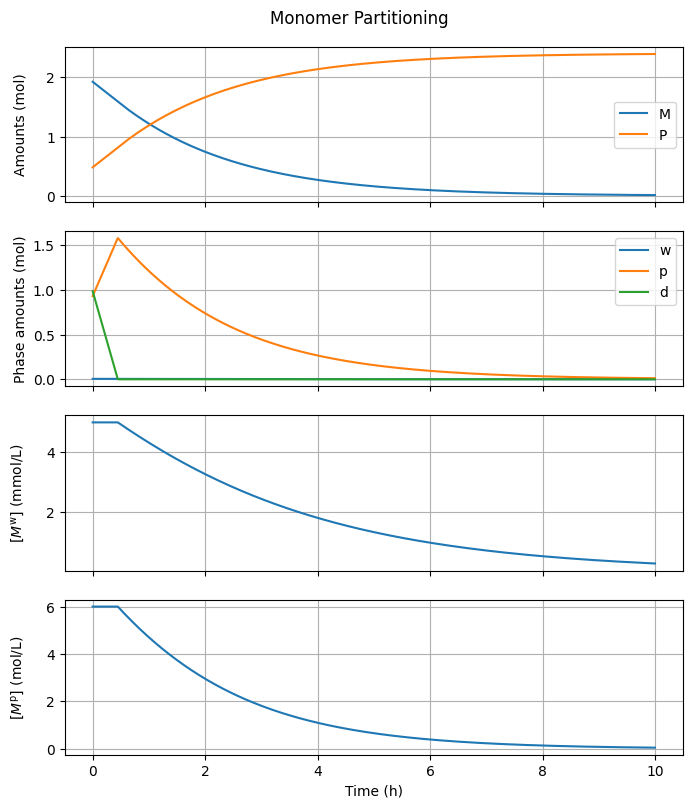

In [22]:
plot_monomer_partitioning(sol_batch_seeded)

Initially, a monomer droplet phase is present, so both the aqueous and particle phases remain saturated. After roughly half an hour, the droplets are depleted; from that point onward, the remaining monomer partitions only between water and polymer particles, and the concentrations in both phases begin to decrease.

#### Surfactant Partitioning

The surfactant balance is equally informative because it determines whether micelles are available for nucleation and how much of the particle surface remains covered.

In [23]:
def plot_surfactant_partitioning(sol: dict) -> None:
    """Plot surfactant partitioning results.

    Parameters
    ----------
    sol : dict
        Model solution.
    """

    fig, ax = plt.subplots(4, sharex=True, figsize=(7, 4*2))
    fig.suptitle("Surfactant Partitioning")
    fig.tight_layout()
    fig.align_ylabels()

    t_hour = sol['t']/3600
    ax[-1].set_xlabel("Time (h)")

    # Moles
    ax[0].plot(t_hour, sol['n'][Ix.S, :], label='S')
    ax[0].set_ylabel("Amount (mol)")
    ax[0].legend(loc='best')
    ax[0].grid(True)

    # Phase split
    n_S = sol['n'][Ix.S]
    for phase in ['w', 'p', 'm']: 
        split = 1e2*np.where(n_S > 1e-6, sol[f"n_S{phase}"] / n_S, 0.0)
        ax[1].plot(t_hour, split, label=phase)
    ax[1].set_ylabel("Phase split (%)")
    ax[1].legend(loc='best')
    ax[1].grid(True)

    # Surfactant concentration in water phase
    ax[2].plot(t_hour, 1e3*sol['Sw'])
    ax[2].set_ylabel(r"$[S^{\mathrm{w}}]$" + " (mmol/L)")
    ax[2].grid(True)

    # Surfactant surface concentration in particle phase
    ax[3].plot(t_hour, 1e6*sol['Sp'])
    ax[3].set_ylabel(r"$\Gamma$" + " (µmol/m²)")
    ax[3].grid(True)

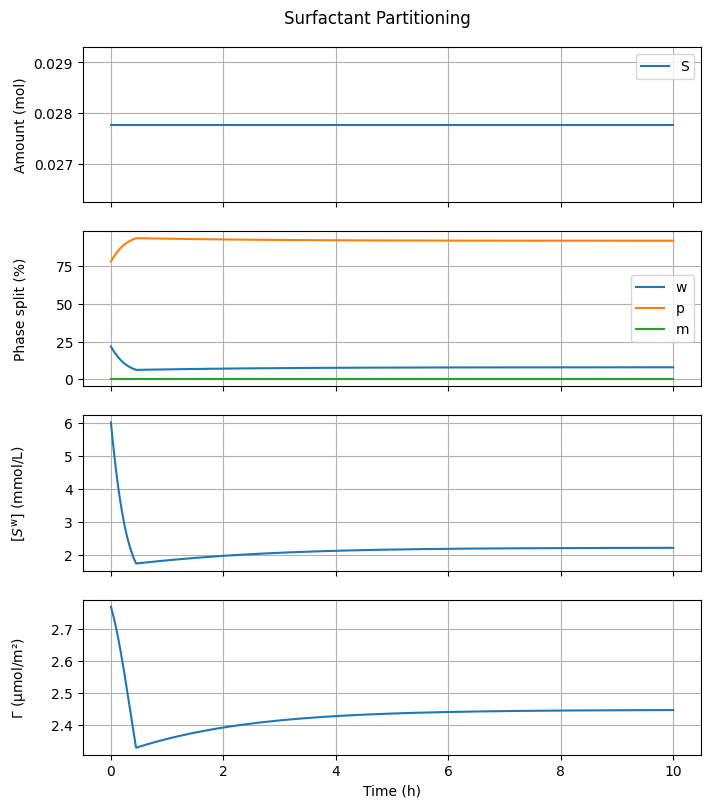

In [24]:
plot_surfactant_partitioning(sol_batch_seeded)

Under these conditions, the surfactant inventory is insufficient to form micelles, so essentially all surfactant partitions between the aqueous phase and the particle surface. As polymerization proceeds, particles grow and adsorb additional surfactant, reducing the amount remaining in the aqueous phase. Once the droplet phase disappears, the particle volume stops increasing and then decreases slightly because the polymer is denser than the monomer; as a result, both $[S^{\mathrm{w}}]$ and $\Gamma$ begin to increase.

#### Particle Size and Number

Finally, we examine the particle population itself.

In [25]:
def plot_particle_size_number(sol: dict) -> None:
    """Plot particle size and number results.

    Parameters
    ----------
    sol : dict
        Model solution.
    """

    fig, ax = plt.subplots(3, sharex=True, figsize=(7, 3*2))
    fig.suptitle("Particle Size and Number")
    fig.tight_layout()
    fig.align_ylabels()

    t_hour = sol['t']/3600
    ax[-1].set_xlabel("Time (h)")

    # Number of particles
    ax[0].plot(t_hour, sol['Np']/sol['Vw'])
    ax[0].set_ylabel("Number (#/L)")
    ax[0].grid(True)

    # Particle diameter
    ax[1].plot(t_hour, 1e9*2*sol['rpu'])
    ax[1].set_ylabel("Diameter (nm)")
    ax[1].grid(True)

    # Nucleation rate
    ax[2].plot(t_hour, sol['rate_nuc']/sol['Vw'])
    ax[2].set_ylabel("Nucleation rate (#/(L·s))")
    ax[2].grid(True)

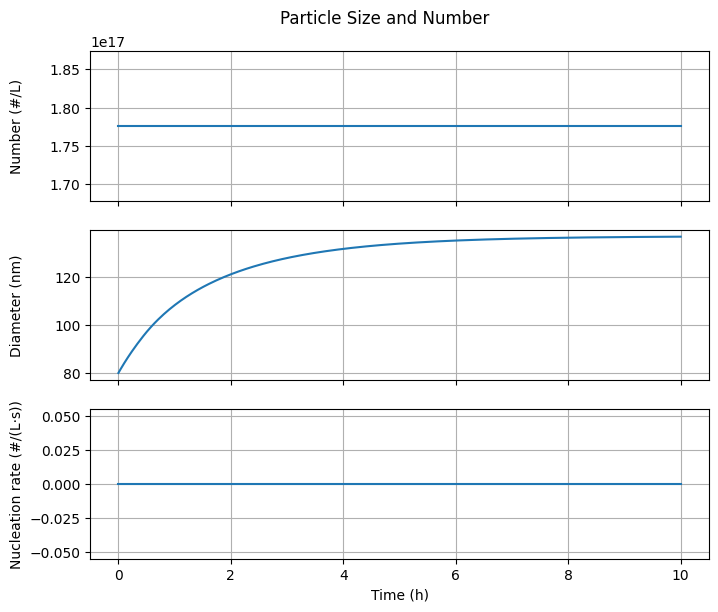

In [26]:
plot_particle_size_number(sol_batch_seeded)

The particle number remains constant, as expected for a seeded system with no micellar nucleation. At the same time, the particle diameter increases steadily due to polymerization within the seed particles.

### Semibatch Seeded Polymerization

We now consider an isothermal seeded semibatch polymerization, again at 50 °C and with an initial seed diameter of 80 nm. The reactor is initially charged with initiator, water, seed, and part of the surfactant. The monomer and the remaining surfactant are then fed over roughly 6 hours. As in the previous case, the surfactant content is kept below the CMC to suppress additional particle formation.

In [27]:
recipe_semibatch_seeded = {
    'tend': 10*3.6e3,  # s
    'm0': np.zeros(len(Ix)),
    'd0': 80e-9,  # m
    'T': lambda t: np.interp(t, [0., 1200., 10*3600.], [20., 50., 50.]),  # °C
    'feed': {  # kg/s
        'I': lambda t: 0.0,
        'M': lambda t: 0.2/(5.67*3600) if (t > 1200 and t < 6*3600) else 0.0,
        'S': lambda t: 3e-7 if (t > 1200 and t < 6*3600) else 0.0,
        'W': lambda t: 0.0
    },
}

recipe_semibatch_seeded['m0'][Ix.I] = 0.003
recipe_semibatch_seeded['m0'][Ix.M] = 0.000
recipe_semibatch_seeded['m0'][Ix.P] = 0.050
recipe_semibatch_seeded['m0'][Ix.S] = 0.004
recipe_semibatch_seeded['m0'][Ix.W] = 1.000

In [28]:
sol_semibatch_seeded = solve_model(recipe_semibatch_seeded, params)

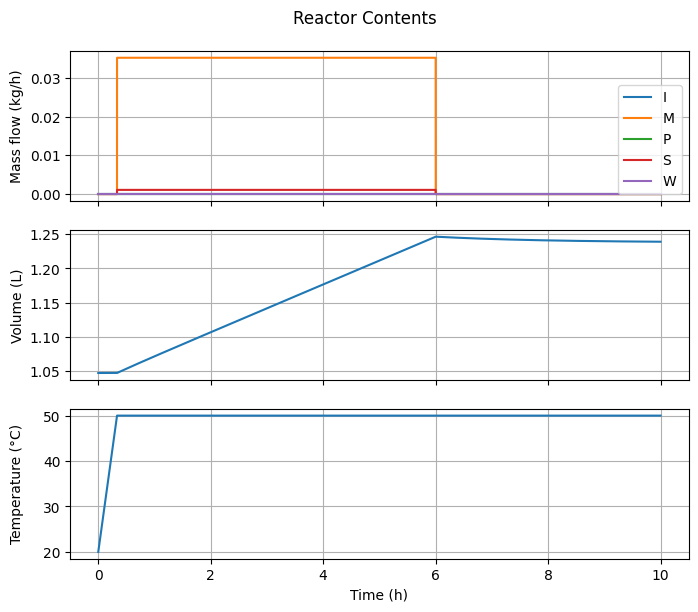

In [29]:
plot_contents(sol_semibatch_seeded)

The reactor temperature is ramped to the target value over the first 20 min. The monomer and surfactant feeds then begin, causing the total volume to increase.

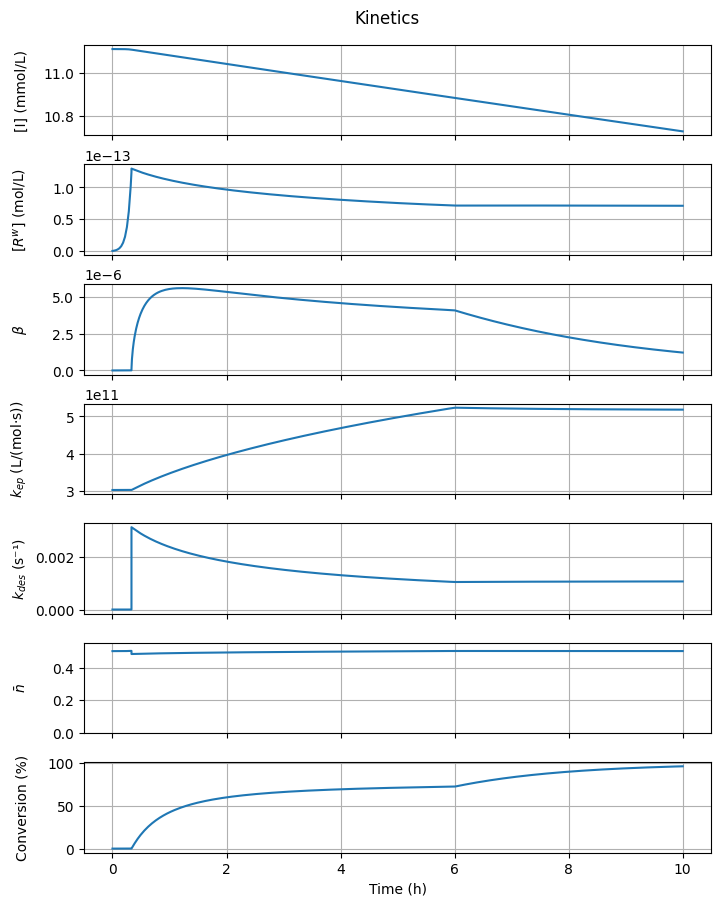

In [30]:
plot_kinetics(sol_semibatch_seeded)

One of the most significant differences compared with the batch process is the conversion profile. During the feed period, the system approaches a quasi-steady state, giving an instantaneous conversion of about 75%. Once the feed stops, the conversion rises progressively toward 100%, as in the batch recipe.

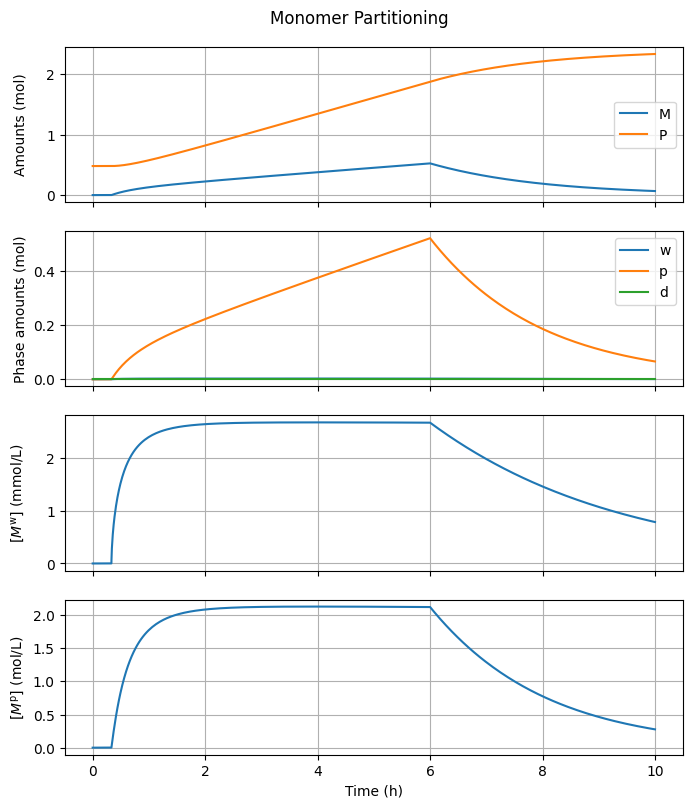

In [31]:
plot_monomer_partitioning(sol_semibatch_seeded)

This quasi-steady state is clearly reflected in the monomer concentration profiles.

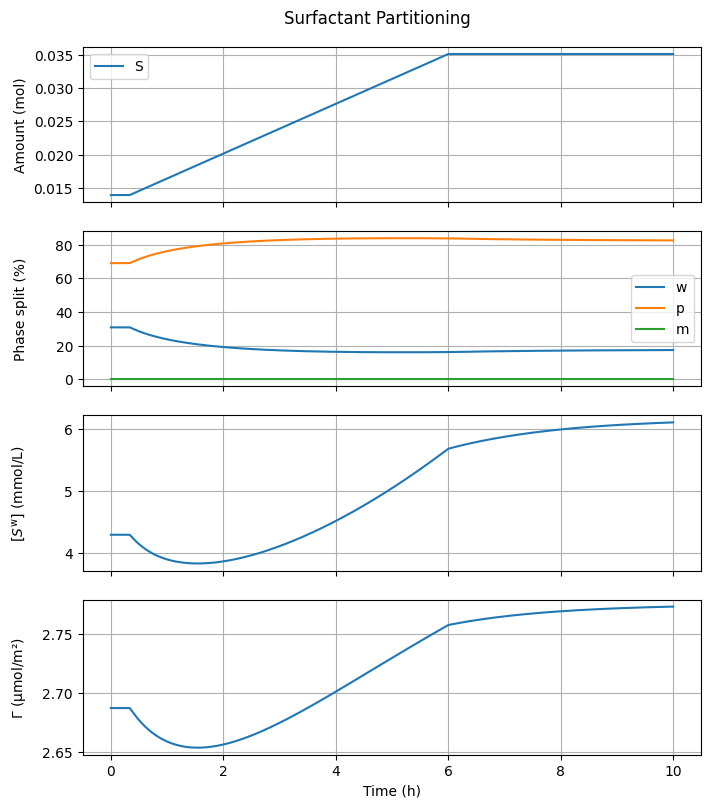

In [32]:
plot_surfactant_partitioning(sol_semibatch_seeded)

The surfactant coverage of the particles remains fairly constant during the run as a result a "matching" surfactant feed.

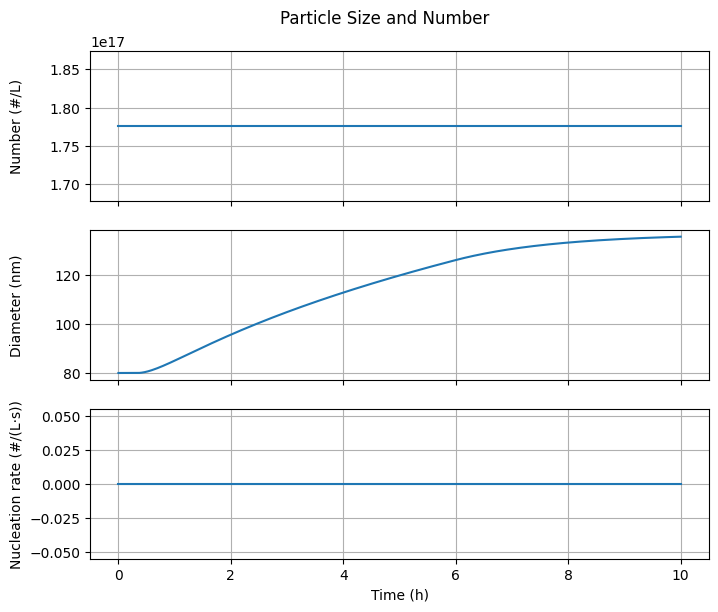

In [33]:
plot_particle_size_number(sol_semibatch_seeded)

As expected, the particle number remains constant, while the diameter increases to essentially the same final level as in the batch recipe, since the amounts of seed polymer and monomer are identical.

### Batch Unseeded Polymerization

As a final case, we consider an unseeded (*ab initio*) batch polymerization. The conditions are identical to those of the earlier seeded case, except for the surfactant content, which is now intentionally set above the CMC. Under these conditions, micelles are present initially and particle nucleation can occur.

In [34]:
recipe_batch_unseeded = {
    'tend': 2*3.6e3,  # s
    'm0': np.zeros(len(Ix)),
    'd0': 1e-9,  # m
    'T': lambda t: 50.0,  # °C
    'feed': {  # kg/s
        'I': lambda t: 0,
        'M': lambda t: 0,
        'S': lambda t: 0,
        'W': lambda t: 0,
    },
}

recipe_batch_unseeded['m0'][Ix.I] = 0.003
recipe_batch_unseeded['m0'][Ix.M] = 0.200
recipe_batch_unseeded['m0'][Ix.P] = 0.000
recipe_batch_unseeded['m0'][Ix.S] = 0.010
recipe_batch_unseeded['m0'][Ix.W] = 1.000

In [35]:
sol_batch_unseeded = solve_model(recipe_batch_unseeded, params)

We begin by examining the evolution of the particle number and particle diameter. These two variables clearly identify the nucleation period and the subsequent growth of the newly formed particles.

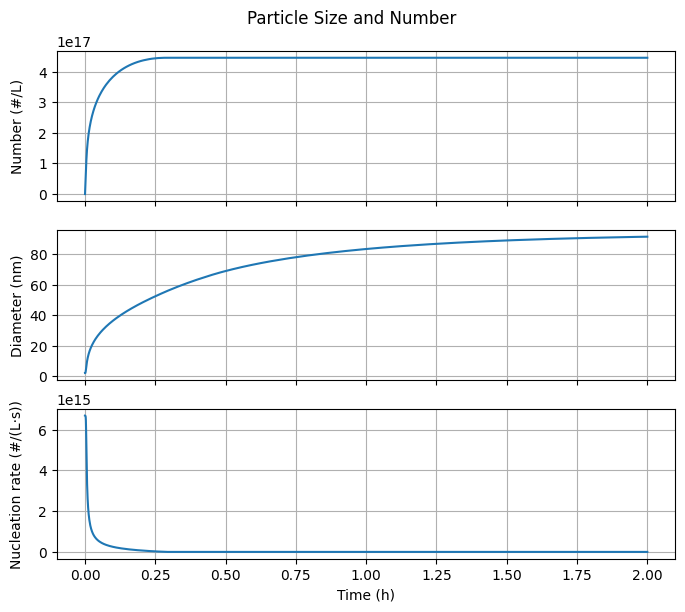

In [36]:
plot_particle_size_number(sol_batch_unseeded)

Under these conditions, the period of particle formation, usually referred to as Interval I, lasts about 15 min. This behavior is also reflected in the surfactant profiles, because micelles are progressively consumed as they give rise to new particles.

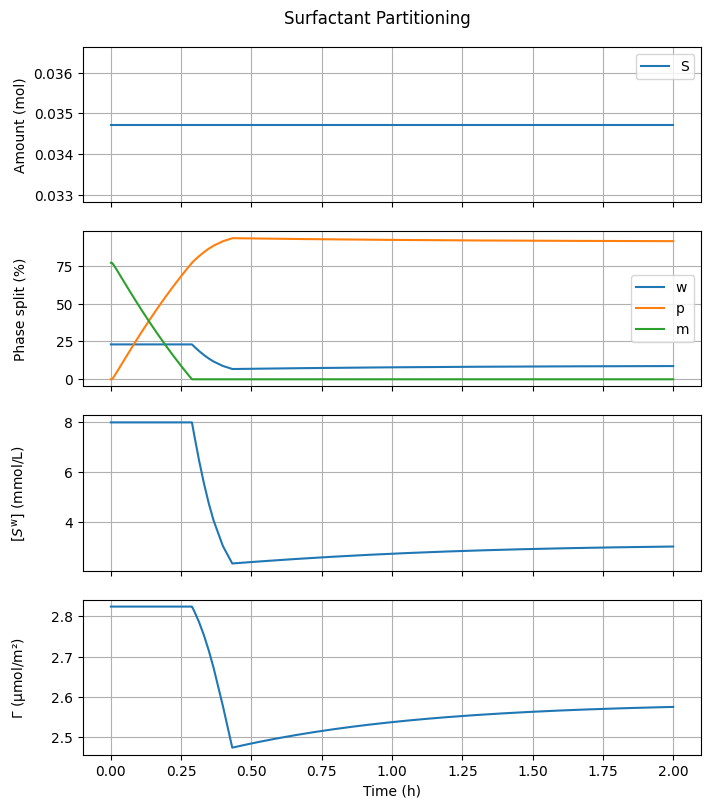

In [37]:
plot_surfactant_partitioning(sol_batch_unseeded)

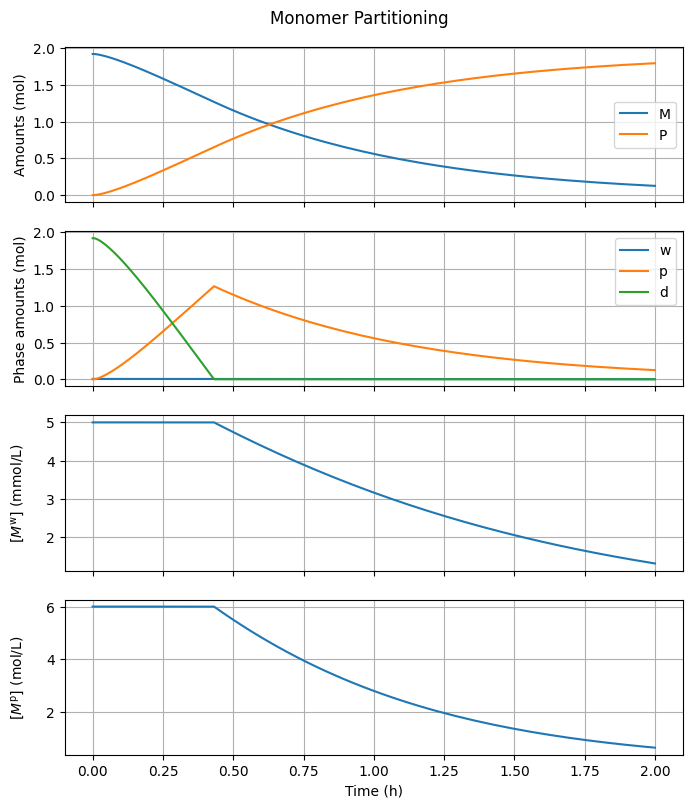

In [38]:
plot_monomer_partitioning(sol_batch_unseeded)

Monomer droplets remain present throughout the entire nucleation period and disappear only after about 0.4 h. The durations of these two intervals are not directly related: particle nucleation is controlled primarily by surfactant and radical entry, whereas droplet depletion follows the overall monomer balance and partitioning.

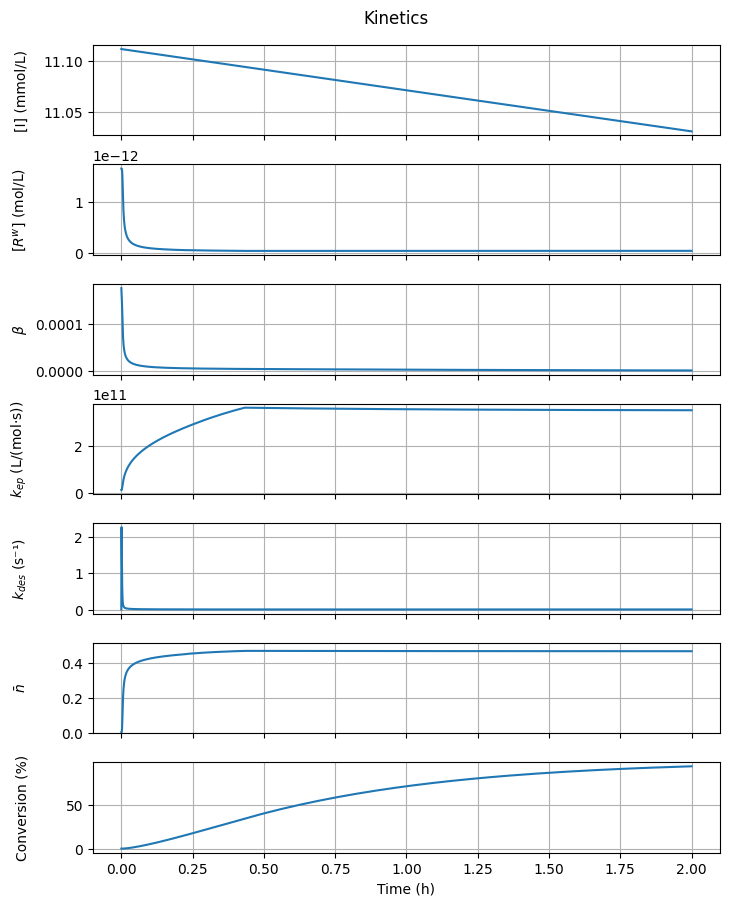

In [39]:
plot_kinetics(sol_batch_unseeded)

The sharp drop in the aqueous-phase radical concentration is caused by the rapid increase in the fraction of radicals absorbed by the newly formed particles. The conversion rate is higher than in the seeded batch case because the unseeded system develops a much larger number of particles, which increases the overall particle-phase polymerization rate according to the expression for $\mathcal{R}^{\mathrm{p}}_{\mathrm{p}}$.

## 🔎 Questions

1. How are the simulation results, particularly $\bar{n}$, affected when the intra-particle termination coefficient $k^{\mathrm{p}}_{\mathrm{t}}$ is increased or decreased by a factor of two? Explain the observed trends.

2. Modify the initial surfactant content in the *ab initio* recipe and investigate its effect on the number of particles, the particle size, and the monomer conversion rate.

3. Search the literature for suitable kinetic and thermodynamic parameters for vinyl acetate (a monomer with higher water solubility), and rerun the simulations using these parameters. How do the results compare with those obtained for the original monomer system?

4. Once the monomer phase disappears, the monomer concentration inside the particles starts to decrease, resulting in a lof of chain mobility. This, in turn, causes a reduction in $k^{\mathrm{p}}_{\mathrm{t}}$, known as the *gel effect*. Search the literature for a suitable expression to describe this effect, implement it in the model, and rerun the simulations. Explain the observed trends.
